In [170]:
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
load_dotenv()

from langchain_community.tools import DuckDuckGoSearchResults

llm = ChatGroq(
    model='openai/gpt-oss-20b',
    temperature=0.1
)


In [171]:
@tool
def personal_info(name:str):
    """Strictly use this function when user ask about some person use this tool when user ask about detail of someone speacif like alice, bob,krishna """
    info = {
        'krishna':'krishna is a member of valorant community which is largest gaming community right now in the world',
        'alice':'alice is the person who is master data science and computer science',
        'bob':'bob is the person who is master of mechanical engineering related concepts and all'
    }
    return info.get(name,'No information of this person')

@tool
def search_duckduckgo(query:str):
    """Use this tool whenever need to call web search or something related to search on internet in short this is your personal websearch use this for websearch"""
    ddg_search = DuckDuckGoSearchResults()
    result = ddg_search.invoke(query)
    return result

@tool 
def search_arxiv(query:str):
    """Use this tool whenever user want anything research related or any research paper or something else"""
    arxiv_search = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_search.invoke(query)

@tool 
def search_wikipedia(query:str):
    """Use this tool whenever user wants to know anything from wikipedia or want to knowledge about something that only available in wikipedia"""
    wikipedia_search = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wikipedia_search.invoke(query)


In [172]:
tools = [search_duckduckgo,search_arxiv,search_wikipedia,personal_info]
llm_with_tools = llm.bind_tools(tools)


In [173]:
result = llm_with_tools.invoke('who is krishna use personal_info tool')
result

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "who is krishna use personal_info tool". So we need to call personal_info with name "Krishna".', 'tool_calls': [{'id': 'fc_93614da8-906b-45c9-abce-8cdb91d648fb', 'function': {'arguments': '{"name":"Krishna"}', 'name': 'personal_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 273, 'total_tokens': 324, 'completion_time': 0.053316795, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.013387287, 'prompt_tokens_details': None, 'queue_time': 0.287097669, 'total_time': 0.066704082}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_57d3604148', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb5fe-bb42-7433-94f4-67187b4d2f58-0', tool_calls=[{'name': 'personal_info', 'args': {'name': 'Krishna'}, 'id': 'fc_93614da8-906b-45c9-abce-8cdb91d648fb', 'type': 'tool_

In [174]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,List
from langchain_core.prompts import ChatPromptTemplate
from langchain.messages import ToolMessage,HumanMessage
class State(TypedDict):
    messages:List


In [175]:
def llm_node(state:State) -> State:
    messages = state['messages']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )
    chain = prompt | llm_with_tools

    response = chain.invoke({'input':messages})

    state['messages'] = messages + [response]

    return {
        "messages": messages + [response]
    }



In [176]:
def tool_node(state: State):
    messages = state["messages"]

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]

        result = tool.invoke(tool_call["args"])

        tool_results.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": messages + tool_results
    }



In [177]:
def descion_node(state:State) -> str:
    if state['messages'][-1].tool_calls:
        return 'tool_call'
    return 'end'

In [178]:
graph = StateGraph(State)
graph.add_node('llm_node',llm_node)
graph.add_node('tool_node',tool_node)


graph.add_edge(START,'llm_node')
graph.add_conditional_edges('llm_node',descion_node,{'tool_call':'tool_node','end':END})
graph.add_edge('tool_node','llm_node')
graph.add_edge('llm_node',END)

reAct_graph = graph.compile()



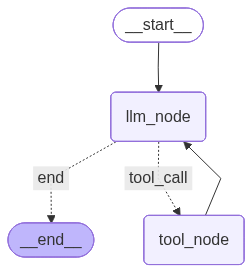

In [179]:
from IPython.display import Image
Image(reAct_graph.get_graph().draw_mermaid_png())



In [183]:
reAct_graph.invoke({"messages": [HumanMessage(content="who is alice using tool")]})

{'messages': [HumanMessage(content='who is alice using tool', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user says: "[HumanMessage(content=\'who is alice using tool\', additional_kwargs={}, response_metadata={})]". They want to know who is Alice. They want to use a tool. The instruction says: "Strictly use this function when user ask about some person use this tool when user ask about detail of someone speacif like alice, bob,krishna". So we should use personal_info function. The query: name: "Alice". Let\'s call the function.', 'tool_calls': [{'id': 'fc_244ca835-477f-4f53-8a2b-e0e4c446e43e', 'function': {'arguments': '{"name":"Alice"}', 'name': 'personal_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 300, 'total_tokens': 421, 'completion_time': 0.125188541, 'completion_tokens_details': {'reasoning_tokens': 98}, 'prompt_time': 0.003422515, 'prompt_tokens_